# Logistic Regression (Loan Approval Prediction)

## Problem Statement

You are working as a Data Analyst in a financial institution. The company wants to build a model to predict whether a loan application will be approved (1) or not approved (0) based on customer details.

The objective of this assignment is to perform Exploratory Data Analysis (EDA), build a Logistic Regression model, evaluate its performance, and interpret the results.

## Q1. Data Loading & Understanding

### Question

a) Load the dataset into Python.

b) Display the first 5 rows.

c) Check the shape of the dataset.

d) Display the data types of each column.

#### Answer :

The dataset is loaded into a Pandas DataFrame. The first five rows are displayed to understand the structure of the dataset. The shape of the dataset is checked to determine the number of rows and columns, and the data types of each column are examined to identify numerical and categorical features.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

%matplotlib inline

In [2]:
# Load the dataset

df = pd.read_excel("loan_approval.xlsx")

In [3]:
# Display first five rows

df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [4]:
# Shape of the dataset

print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 8)


In [5]:
# Information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


In [6]:
# Data types of all columns

df.dtypes

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

## Q2. Data Cleaning

### Question

a) Check for missing values in the dataset.

b) Handle missing values appropriately.

c) Identify categorical columns present in the dataset.

#### Answer :

Data cleaning is an important step in the Machine Learning workflow. It involves checking for missing values, handling them appropriately, and identifying categorical variables that require preprocessing before model building.

In [8]:
# Check for missing values

df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

### Observation

The output shows that all columns contain **0 missing values**. Therefore, no missing value treatment is required.

In [9]:
# Identify categorical columns

categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

print("Categorical Columns:")
categorical_cols

Categorical Columns:


Index(['name', 'city', 'loan_approved'], dtype='object')

In [11]:
# Display unique values of categorical columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


name
['Allison Hill' 'Brandon Hall' 'Rhonda Smith' ... 'Brandon Meyer'
 'Jason Price' 'Nicole Brown']

city
['East Jill' 'New Jamesside' 'Lake Roberto' ... 'East Haley' 'Adamland'
 'New Nathantown']

loan_approved
[False  True]


In [12]:
# Check duplicate records

print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


### Observation

The categorical columns in the dataset are:

- name
- city
- loan_approved

## Q3. Exploratory Data Analysis (EDA)

### Question

a) Plot the distribution of the target variable.

b) Analyze the relationship between one numerical feature and the target variable.

c) Analyze the relationship between Years of Employment and the target variable.

#### Answer :

Exploratory Data Analysis (EDA) helps us understand the distribution of the target variable and identify relationships between the features and the target. This helps in understanding the data before building the Logistic Regression model.

### (a) Distribution of the Target Variable

The following count plot shows the number of approved and not approved loan applications in the dataset.

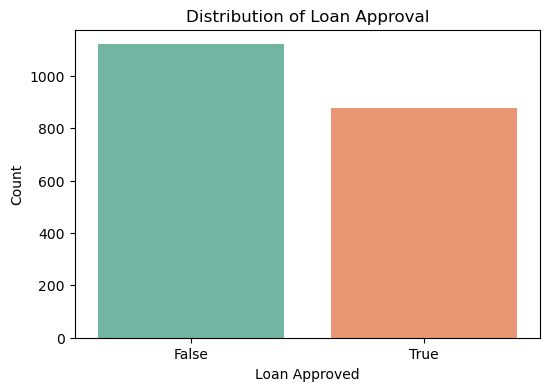

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='loan_approved',
    hue='loan_approved',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Count")

plt.show()


### Observation

The count plot shows the distribution of approved and not approved loan applications. This helps determine whether the dataset is balanced or imbalanced.

### (b) Relationship between Income and Loan Approval

A boxplot is used to compare the income distribution of customers whose loans were approved and those whose loans were not approved.

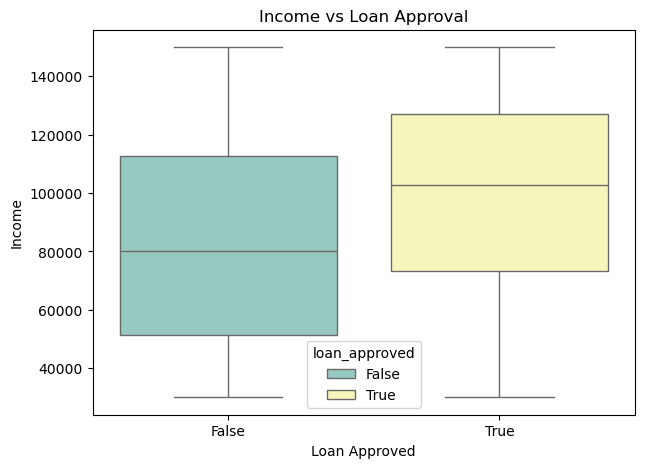

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='loan_approved',
    y='income',
    hue='loan_approved',
    data=df,
    palette='Set3'
)

plt.title("Income vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Income")

plt.show()

### Observation

The boxplot compares the income levels of customers with approved and not approved loans. It helps identify whether higher income is associated with a greater likelihood of loan approval.

### (c) Relationship between Years of Employment and Loan Approval

The following boxplot shows the distribution of years of employment for approved and not approved loan applications.

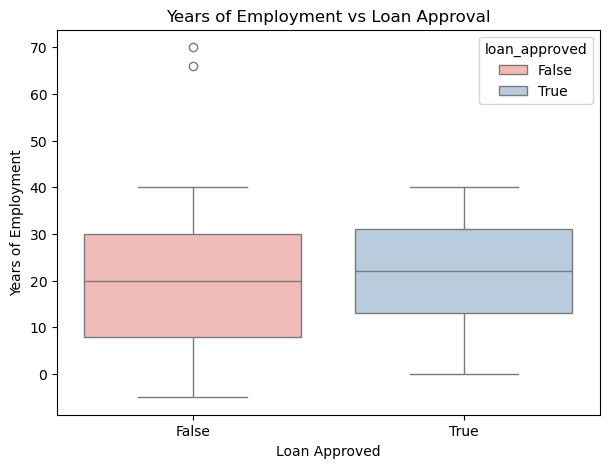

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='loan_approved',
    y='years_employed',
    hue='loan_approved',
    data=df,
    palette='Pastel1'
)

plt.title("Years of Employment vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Years of Employment")

plt.show()

### Observation

The boxplot compares the years of employment of customers based on loan approval status.

If the approved group generally has higher years of employment, it suggests that longer employment history may positively influence loan approval decisions.

## Q4. Outlier Detection and Treatment

### Question

a) Detect outliers in numerical columns using the IQR method.

b) Treat outliers using capping techniques.

#### Answer :

Outliers are extreme values that differ significantly from the rest of the observations. They can affect the performance of Machine Learning models.

The Interquartile Range (IQR) method is used to detect outliers.

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Outliers are treated using the capping method, where values outside the lower and upper bounds are replaced with the respective boundary values.

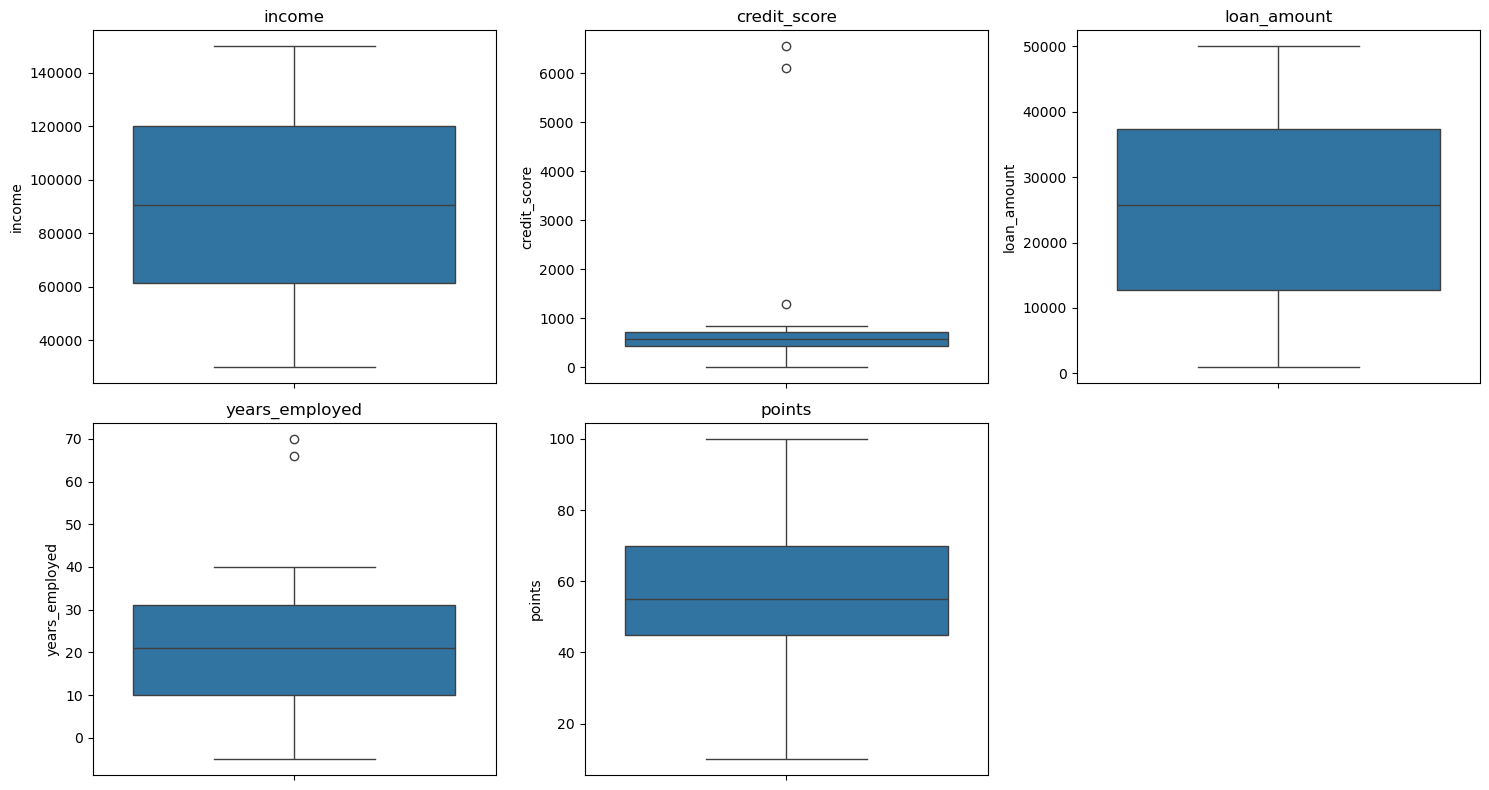

In [18]:
# Numerical columns

numerical_cols = ['income', 'credit_score', 'loan_amount',
                  'years_employed', 'points']

# Boxplots before treatment

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
# IQR Capping

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

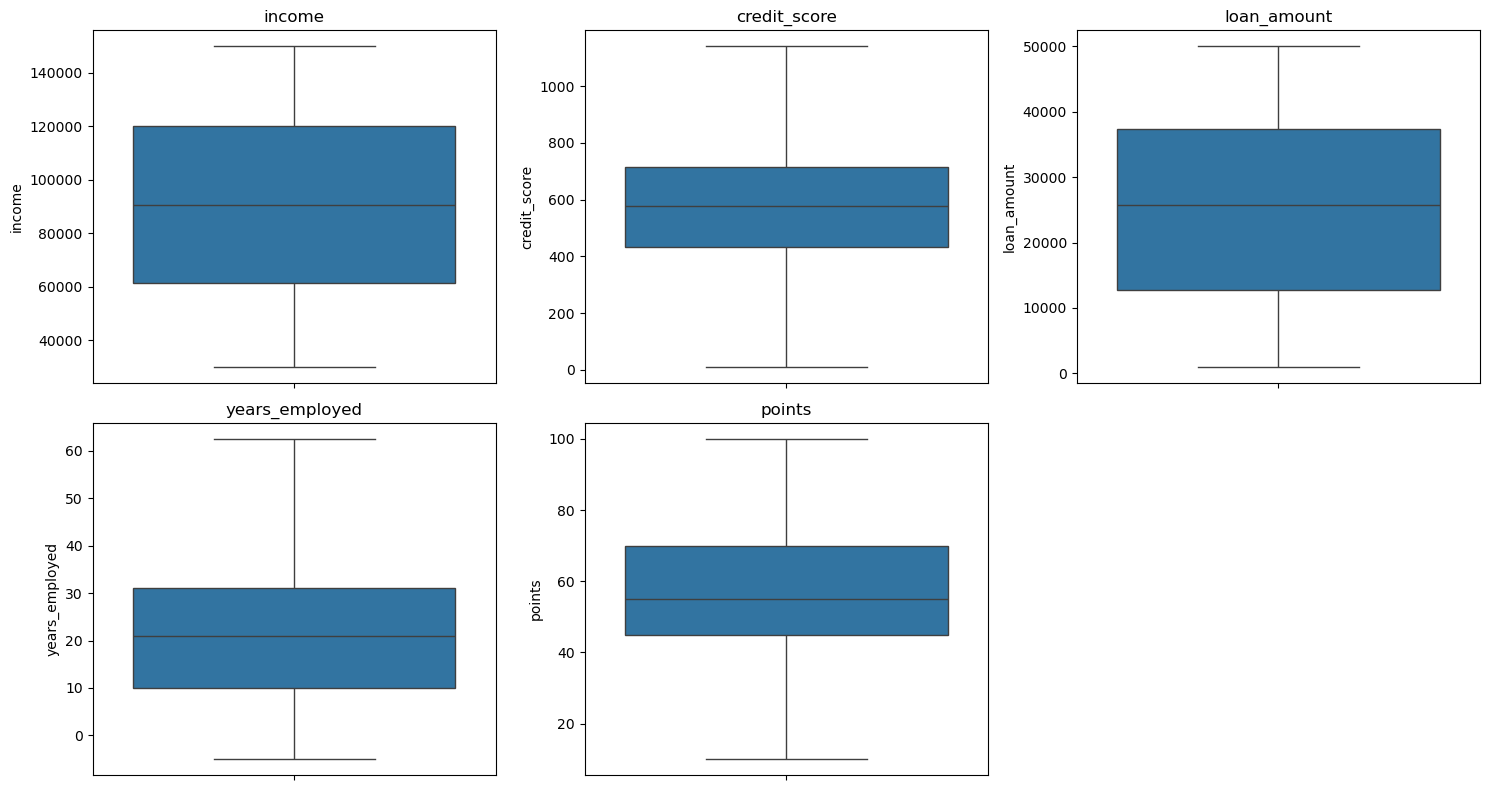

In [20]:
# Boxplots after treatment

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Observation

The numerical variables were checked for outliers using the IQR method. Any detected outliers were treated using the capping technique to reduce their impact on the Logistic Regression model.

## Q5. Convert Target Variable into Numerical Format Suitable for Model Building and Drop Unnecessary Columns.

#### Answer :

The target variable is converted into numerical format because Logistic Regression requires numerical target values.

The columns **name** and **city** are identifiers/categories that are not required for model building, so they are removed.

In [21]:
# Convert target variable

df['loan_approved'] = df['loan_approved'].astype(int)

# Drop unnecessary columns

df = df.drop(['name','city'], axis=1)

df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810.0,389.0,39698.0,27.0,50.0,0
1,44592.0,729.0,15446.0,28.0,55.0,0
2,33278.0,584.0,11189.0,13.0,45.0,0
3,127196.0,344.0,48823.0,29.0,50.0,0
4,66048.0,496.0,47174.0,4.0,25.0,0


## Q6. Feature Selection and Data Splitting

### Question

a) Separate independent variables (X) and dependent variable (y).

b) Split the dataset into training and testing sets.

#### Answer :

The independent variables are used to predict the target variable.

The dataset is divided into training data (80%) and testing data (20%) to evaluate the model on unseen data.

In [22]:
# Features and Target

X = df.drop('loan_approved', axis=1)

y = df['loan_approved']

In [23]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1600, 5)
Testing Data: (400, 5)


## Q7. Apply Feature Scaling to the Dataset using StandardScaler.

#### Answer :

Feature scaling standardizes numerical variables so that they have a mean of 0 and a standard deviation of 1. This improves the performance of Logistic Regression.

In [24]:
# Standard Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Q8. Logistic Regression Model Building

### Question

a) Train a Logistic Regression model.

b) Predict the output for test data.

#### Answer :

A Logistic Regression model is trained using the training dataset. The trained model is then used to predict the loan approval status for the testing dataset.

In [26]:
# Train Model

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
# Prediction

y_pred = model.predict(X_test)

comparison = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred

})

comparison.head(10)

,Actual,Predicted
1860,0,0
353,1,1
1333,1,1
905,1,1
1289,1,1
1273,1,1
938,0,0
1731,1,1
65,0,0
1323,1,1


## Q9. Model Evaluation – Confusion Matrix

### Question

a) Generate the confusion matrix.

b) Interpret the results.

#### Answer :

The confusion matrix compares the actual values with the predicted values and helps evaluate the performance of the classification model.

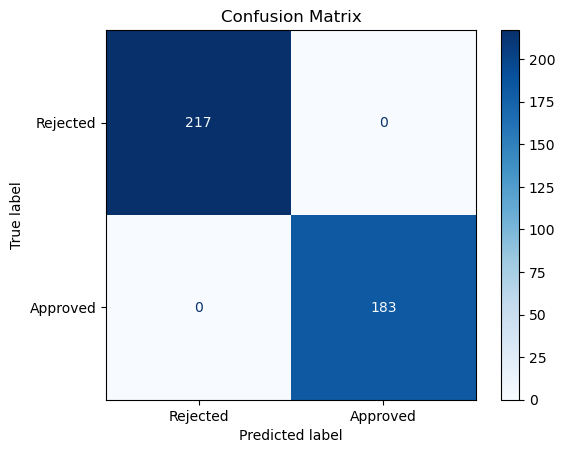

In [28]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,
    display_labels=["Rejected","Approved"]

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [29]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print()

print(classification_report(y_test, y_pred))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       217
           1       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



### Observation

The confusion matrix shows the number of correctly and incorrectly classified loan applications.

The classification report provides Precision, Recall, F1-score, and Accuracy, which help evaluate the overall performance of the Logistic Regression model.

## Q10. Model Evaluation – ROC Curve & AUC

### Question

a) Plot the ROC Curve.

b) Calculate the AUC Score.

#### Answer :

The ROC Curve illustrates the performance of the Logistic Regression model at different classification thresholds.

The Area Under the Curve (AUC) measures the model's ability to distinguish between approved and rejected loan applications.

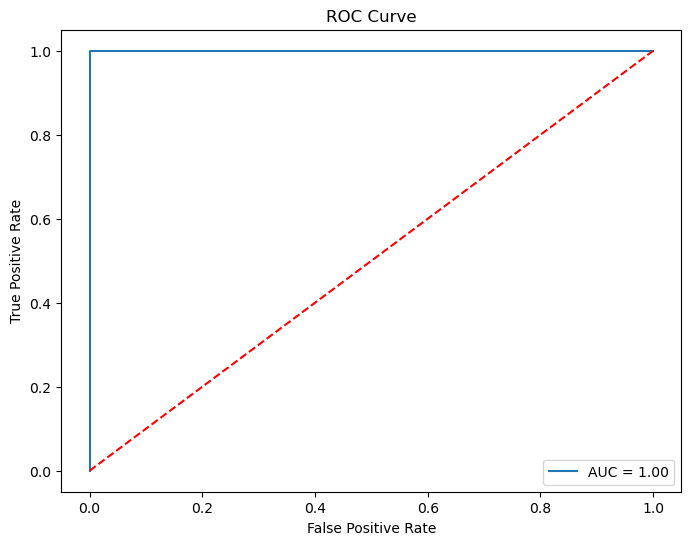

In [30]:
# Probability Prediction

y_prob = model.predict_proba(X_test)[:,1]

# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [31]:
print("AUC Score:", auc)

AUC Score: 1.0


### Observation

The ROC Curve illustrates the trade-off between the True Positive Rate and the False Positive Rate.

A higher AUC score indicates better classification performance.

An AUC value close to 1 indicates an excellent model, while a value close to 0.5 indicates poor classification performance.

# Conclusion

The Loan Approval dataset was successfully analyzed using Logistic Regression.

The dataset was cleaned, explored, and preprocessed before model building. Outliers were treated using the IQR capping technique, the target variable was converted into numerical format, and feature scaling was applied.

The Logistic Regression model was trained and evaluated using the Confusion Matrix, Accuracy Score, Classification Report, ROC Curve, and AUC Score.

Overall, the model provides an effective approach for predicting whether a loan application is likely to be approved based on the given customer information.